# Day 16 - Sentence Embeddings & Semantic Search

This notebook demonstrates:

1. Creating **384-dimensional sentence embeddings**
2. Measuring semantic similarity using cosine similarity
3. Building a tiny semantic search engine
4. Visualizing embeddings using PCA

Model: `all-MiniLM-L6-v2` (384 dimensions)


In [ ]:
# Uncomment if needed
# !pip install sentence-transformers scikit-learn matplotlib pandas


In [2]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Load the model that will be used for generating the embeddings
model = SentenceTransformer("all-MiniLM-L6-v2")
print("Model loaded.")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Model loaded.


In [3]:
documents = [
"The employee receives 18 days of annual leave.",
"Employees are entitled to eighteen vacation days every year.",
"The medical leave policy allows 10 days.",
"Travel expenses require manager approval.",
"Laptops are replaced every four years.",
"Python is a popular programming language.",
"Java is widely used in enterprise software.",
"The weather in Bangalore is pleasant.",
"Today's stock market closed higher.",
"Machine learning models require data."
]

df = pd.DataFrame({"Documents":documents})
df

,Document
0,The employee receives 18 days of annual leave.
1,Employees are entitled to eighteen vacation da...
2,The medical leave policy allows 10 days.
3,Travel expenses require manager approval.
4,Laptops are replaced every four years.
5,Python is a popular programming language.
6,Java is widely used in enterprise software.
7,The weather in Bangalore is pleasant.
8,Today's stock market closed higher.
9,Machine learning models require data.


#### Calculating the vector for each sentence
* Coverting a 'sentence' to a vector of numbers is not as easy as ```<lattitude, longitude>``` vector calculation (which works on a 2D Geo-spatial surface)
* We need trained models to do that job, as the number of dimensions is way more than *two* - i.e. **384**. This is also known as _EMBEDDING_.
* We are using (HuggingFace based pretrained model). Details: [https://huggingface.co/docs/transformers/en/main_classes/model#transformers.PreTrainedModel.from_pretrained]

In [25]:
embeddings = model.encode(documents)

print("Embedding matrix shape:", embeddings.shape)
print("Dimensions per embedding:", embeddings.shape[1])

print("\nFirst 10 values of first embedding:")
document_1 = documents[0]
print(len(embeddings[0]))
embedding_1_trimmed = np.round(embeddings[0][:10],3)
print(f"{document_1} -->      {embedding_1_trimmed}")

Embedding matrix shape: (10, 384)
Dimensions per embedding: 384

First 10 values of first embedding:
384
The employee receives 18 days of annual leave. -->      [ 0.036  0.117  0.047  0.007  0.     0.054 -0.033 -0.064 -0.032 -0.052]


In [26]:
sim = cosine_similarity(embeddings)
sim_df = pd.DataFrame(np.round(sim,3))
sim_df

,0,1,2,3,4,5,6,7,8,9
0,1.000,0.686,0.603,0.256,0.220,-0.003,0.051,0.045,0.009,-0.036
1,0.686,1.000,0.460,0.326,0.340,-0.002,0.109,0.040,0.010,0.046
2,0.603,0.460,1.000,0.170,0.174,-0.022,-0.021,-0.003,-0.050,0.037
3,0.256,0.326,0.170,1.000,0.096,-0.053,0.059,-0.052,-0.020,0.190
4,0.220,0.340,0.174,0.096,1.000,0.089,0.195,0.011,0.021,0.178
5,-0.003,-0.002,-0.022,-0.053,0.089,1.000,0.429,0.019,0.115,0.140
6,0.051,0.109,-0.021,0.059,0.195,0.429,1.000,0.051,0.150,0.151
7,0.045,0.040,-0.003,-0.052,0.011,0.019,0.051,1.000,0.085,-0.011
8,0.009,0.010,-0.050,-0.020,0.021,0.115,0.150,0.085,1.000,-0.011
9,-0.036,0.046,0.037,0.190,0.178,0.140,0.151,-0.011,-0.011,1.000


##### Similarity Scores
Notice that the two annual leave sentences have a very high cosine similarity despite using different wording.

| Relationship            |   Typical Cosine |
| ----------------------- | ---------------: |
| Identical               |        0.95–1.00 |
| Very similar            |        0.80–0.95 |
| Related                 |        0.50–0.80 |
| Weakly related          |        0.20–0.50 |
| Unrelated               |        0.00–0.20 |
| Opposite/very different | Occasionally < 0 |


In [27]:
from ipywidgets import interact, Dropdown

def compare(doc1,doc2):
    i=documents.index(doc1)
    j=documents.index(doc2)
    score=cosine_similarity([embeddings[i]],[embeddings[j]])[0][0]
    print("Sentence 1:\n",doc1)
    print("\nSentence 2:\n",doc2)
    print(f"\nCosine Similarity = {score:.4f}")

interact(compare,
         doc1=Dropdown(options=documents,value=documents[0]),
         doc2=Dropdown(options=documents,value=documents[1]));

interactive(children=(Dropdown(description='doc1', options=('The employee receives 18 days of annual leave.', …

In [28]:
def semantic_search(query,top_k=3):
    q=model.encode([query])
    scores=cosine_similarity(q,embeddings)[0]
    idx=np.argsort(scores)[::-1][:top_k]

    print("Query:",query)
    print("-"*60)
    for rank,i in enumerate(idx,1):
        print(f"{rank}. Score={scores[i]:.4f}")
        print(documents[i])
        print()

semantic_search("How many vacation days do employees receive?")


Query: How many vacation days do employees receive?
------------------------------------------------------------
1. Score=0.8281
Employees are entitled to eighteen vacation days every year.

2. Score=0.6412
The employee receives 18 days of annual leave.

3. Score=0.4406
The medical leave policy allows 10 days.



In [29]:
query="Python language"

semantic_search(query, top_k=12)

Query: Python language
------------------------------------------------------------
1. Score=0.8090
Python is a popular programming language.

2. Score=0.2610
Java is widely used in enterprise software.

3. Score=0.1312
Machine learning models require data.

4. Score=0.0390
The employee receives 18 days of annual leave.

5. Score=0.0365
Laptops are replaced every four years.

6. Score=0.0266
Today's stock market closed higher.

7. Score=0.0138
The weather in Bangalore is pleasant.

8. Score=-0.0001
Employees are entitled to eighteen vacation days every year.

9. Score=-0.0019
The medical leave policy allows 10 days.

10. Score=-0.0295
Travel expenses require manager approval.



#### 2D Approx Plot
* Due to human brain limitations, we cannot visualize 384 dimensions. However, we can approximately re-map 384 dimensions into 2D.
* This approximation works on the principal of **Projections** or *Shadowing*. This is similar to how we _see shadows of a 3D world objects onto 2D surface_. This works in the same way, as _"looking into a shadow we can make a mental image of the object - whether it's a human or a cow!"_
* One of the techniques used to obtain shadows (or projections) is by use **PCA** or **Principal Component Analysis** (beyond the scope of this bootcamp). For enthusiastic readers, here is the link for self-study: [https://www.miketipping.com/papers/met-mppca.pdf]
* Let's see how the landscape of the shadow-vectors look in 2D, for each of the 10 documents.

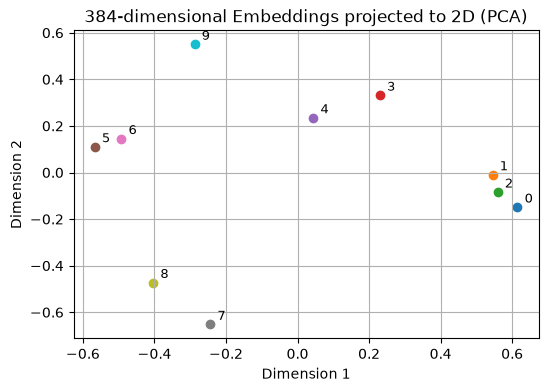

,ID,Document
0,0,The employee receives 18 days of annual leave.
1,1,Employees are entitled to eighteen vacation da...
2,2,The medical leave policy allows 10 days.
3,3,Travel expenses require manager approval.
4,4,Laptops are replaced every four years.
5,5,Python is a popular programming language.
6,6,Java is widely used in enterprise software.
7,7,The weather in Bangalore is pleasant.
8,8,Today's stock market closed higher.
9,9,Machine learning models require data.


In [34]:
pca=PCA(n_components=2)
coords=pca.fit_transform(embeddings)

plt.figure(figsize=(6,4))

for i,(x,y) in enumerate(coords):
    plt.scatter(x,y)
    plt.text(x+0.02,y+0.02,str(i),fontsize=9)

plt.title("384-dimensional Embeddings projected to 2D (PCA)")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.grid(True)
plt.show()

display(pd.DataFrame({
    "ID":range(len(documents)),
    "Document":documents
}))

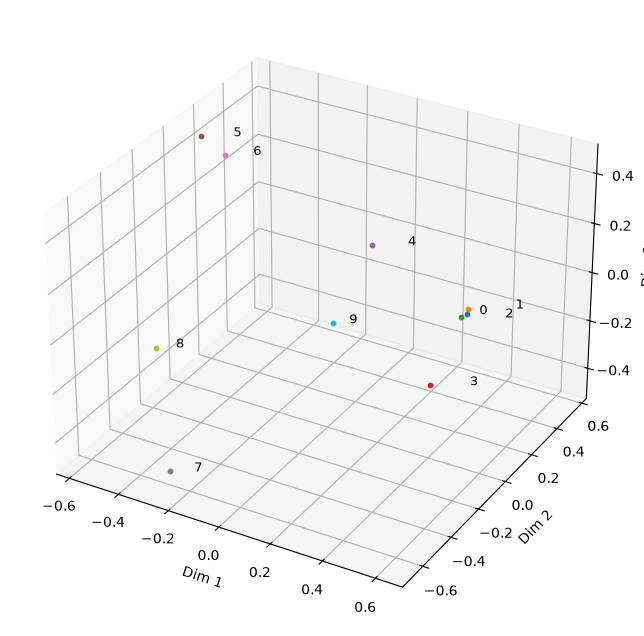

,ID,Document
0,0,The employee receives 18 days of annual leave.
1,1,Employees are entitled to eighteen vacation da...
2,2,The medical leave policy allows 10 days.
3,3,Travel expenses require manager approval.
4,4,Laptops are replaced every four years.
5,5,Python is a popular programming language.
6,6,Java is widely used in enterprise software.
7,7,The weather in Bangalore is pleasant.
8,8,Today's stock market closed higher.
9,9,Machine learning models require data.


In [51]:
pca=PCA(n_components=3)
coords=pca.fit_transform(embeddings)

fig = plt.figure(figsize=(12,8))
ax = fig.add_subplot(111, projection="3d")

for i, txt in enumerate(documents):
    ax.scatter(coords[i,0], coords[i,1], coords[i,2], s=10)
    ax.text(coords[i,0], coords[i,1], coords[i,2],
            ((" "*(3+(10-i)%10))+ str(i)), fontsize=9)

ax.set_xlabel("Dim 1")
ax.set_ylabel("Dim 2")
ax.set_zlabel("Dim 3")

plt.show()

display(pd.DataFrame({
    "ID":range(len(documents)),
    "Document":documents
}))


## Discussion Questions

1. Why are the first two HR policy sentences close together?
2. Like the ```<Lattitude and Longitude>``` 2D vector,
do we really need to understand what does each of the 384 dimensions represent in an embedding?
3. Why is it easier to visualize vectors in 2D or 3D?
4. Why is the 'Python' sentence far from the 'Weather' sentence?
5. Why doesn't semantic search require exact keywords?
6. What's the role of Model ```'all-MiniLM-L6-v2'``` in obtaining the embedding vectors?
7. Why do we need a vector database once we have millions of embeddings?

### Bridge to Day 17

```
PDF
   ↓
Chunking
   ↓
Embeddings (384 dimensions)
   ↓
Qdrant
   ↓
Semantic Search
   ↓
LLM
```
